# Classifying Sounds From UrbanSound8K

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import soundata
import librosa
import os

from dotenv import load_dotenv
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


## Load Dataset

In [8]:
# Load .env file
load_dotenv()

# Define home path for soundata
data_home = os.getenv("SOUND_DATA_HOME")

print(data_home)

if data_home is None:
    raise EnvironmentError("SOUND_DATA_HOME env var not set")
print(data_home)

/Users/MarcusGallardo/sound_datasets


### Download Dataset

In [ ]:
# dataset = soundata.initialize("urbansound8k", data_home=os.path.join(data_home, "urbansound8k"))
# dataset.download(force_overwrite=True)

# Verify dataset location
# print(dataset.data_home)

INFO: Downloading ['all', 'index']. Index is being stored in C:\Users\mgall\anaconda3\envs\ml-is\Lib\site-packages\soundata\datasets\indexes, and the rest of files in C:\tmp\sound_datasets
INFO: [all] downloading UrbanSound8K.tar.gz
5.61GB [05:37, 17.9MB/s]                                
INFO: C:\tmp\sound_datasets\UrbanSound8K.tar.gz already exists. Run with force_overwrite=True to download from scratch
INFO: [index] downloading urbansound8k_index_1.0.json
1.15MB [00:01, 673kB/s]                             

C:\tmp\sound_datasets


In [ ]:
# Verify dataset location
# print(dataset.data_home)
# metadata_path = os.path.join(dataset.data_home, "metadata", "UrbanSound8K.csv")
# print("Metadata JSON exists?", os.path.exists(metadata_path))

C:\tmp\sound_datasets
Metadata JSON exists? False


## Extract subset of clips for training

In [14]:
# Load metadata from csv file
metadata_path = os.path.join(data_home, "urbansound8k/metadata/UrbanSound8K.csv")
metadata = pd.read_csv(metadata_path)

# Only examine samples from these classes
selected_classes = ['dog_bark', 'car_horn', 'children_playing', 'drilling']

# Filter metadata to only contain selected classes
metadata = metadata[metadata['class'].isin(selected_classes)]

# Load dataset
dataset = soundata.initialize("urbansound8k", data_home=os.path.join(data_home, "urbansound8k"))

# Filter clips based on selected classes
# print(dataset.clip_ids)
clip_subset = [clip for clip in dataset.clip_ids if dataset.clip(clip).tags.labels[0] in selected_classes]

## Training KNN Model on MFCCs

### Extract MFCC Features Using Librosa for KNN

In [ ]:
def extract_features_knn(clip):

    # Number of Mel-Frequency Cepstral Coefficients to extract
    n_mfcc = 13

    wave, sample_rate = clip.audio

    # Extract MFCC
    mfcc = librosa.feature.mfcc(y=wave, sr=sample_rate, n_mfcc=n_mfcc)

    # Compute width based on number of frames
    # Delta calculation requires an odd width that is less than the number of frames
    frame_count = mfcc.shape[1]
    width = min(9, frame_count if frame_count % 2 == 1 else frame_count - 1)
    width = max(width, 3) 

    # Extract mean and std for mfcc and first and second delta of mfcc
    # Examining deltas allows for insights into how mfcc (and therefore tone) changes over time
    delta = librosa.feature.delta(mfcc, order=1, width=width)
    delta2 = librosa.feature.delta(mfcc, order=2, width=width)

    # Concatenate features into a single feature vector
    features = np.concatenate([
        np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
        np.mean(delta, axis=1), np.std(delta, axis=1),
        np.mean(delta2, axis=1), np.std(delta2, axis=1)
    ])

    return features


In [ ]:
# Model should be determining label based on mfcc features, so X is mfcc features and y is clip label
X_mfcc = []
y_labels = []

# Extract features and labels for each clip in the subset
for clip in clip_subset:
    features = extract_features_knn(dataset.clip(clip))
    X_mfcc.append(features)
    y_labels.append(dataset.clip(clip).tags.labels[0])

X_mfcc = np.array(X_mfcc)
y_labels = np.array(y_labels)

### Encode String Labels

In [27]:
# Most models require numerical labels, so encode string labels to integers
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_labels)

### Train Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_mfcc, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

### Create Pipeline

In [19]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

### Tune Hyperparameters

In [20]:
knn_param_grid = [
    {
        "knn__n_neighbors": np.arange(1, 31), # Random nunber searched between 1 and 30 neighbors
        "knn__weights": ["uniform", "distance"], 
        "knn__p": [1, 2], # Use different distance metrics (Manhattan vs. Euclidian)
    }
]

knn_rnd_search = RandomizedSearchCV(knn_pipeline, param_distributions=knn_param_grid, n_iter=20, cv=5, scoring="accuracy", random_state=42, n_jobs=1)

### Fit KNN

In [21]:
# Fit model
knn_rnd_search.fit(X_train, y_train)

print("Best params:", knn_rnd_search.best_params_)
print("Best CV score:", knn_rnd_search.best_score_)

knn_y_pred = knn_rnd_search.predict(X_test)

Best params: {'knn__weights': 'uniform', 'knn__p': 1, 'knn__n_neighbors': np.int64(1)}
Best CV score: 0.9125098054857539


### Evaluation of KNN

                  precision    recall  f1-score   support

        car_horn       0.93      0.72      0.81        86
children_playing       0.83      0.96      0.89       200
        dog_bark       0.95      0.88      0.91       200
        drilling       0.96      0.96      0.96       200

        accuracy                           0.91       686
       macro avg       0.92      0.88      0.89       686
    weighted avg       0.91      0.91      0.91       686



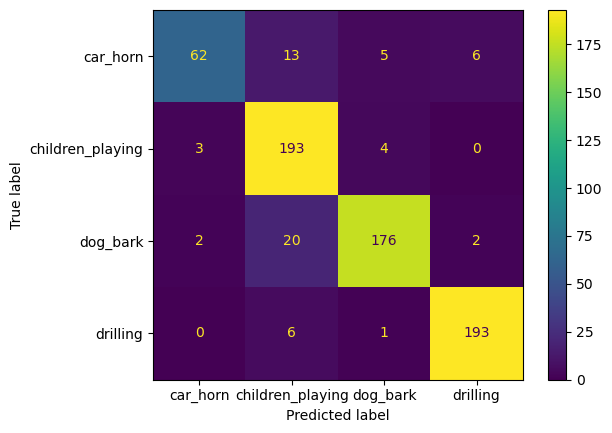

In [22]:
# Convert back to string labels
y_pred_labels = encoder.inverse_transform(knn_y_pred)
y_test_labels = encoder.inverse_transform(y_test)

# Get classification report
print(classification_report(y_test_labels, y_pred_labels))

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels)
plt.show()

## Training CNN on MFCCs

### Extract MFCC features for CNN

In [44]:
# Number of Mel-Frequency Cepstral Coefficients to extract
N_MFCC = 13

# Max number of frames to pad/truncate to
N_FRAMES = 120

def extract_features_cnn(clip):
    wave, sample_rate = clip.audio

    # Extract MFCC
    mfcc = librosa.feature.mfcc(y=wave, sr=sample_rate, n_mfcc=N_MFCC)

     # Compute width based on number of frames
    # Delta calculation requires an odd width that is less than the number of frames
    frame_count = mfcc.shape[1]
    width = min(9, frame_count if frame_count % 2 == 1 else frame_count - 1)
    width = max(width, 3) 

    # Examining deltas allows for insights into how mfcc (and therefore tone) changes over time
    delta = librosa.feature.delta(mfcc, order=1, width=width)
    delta2 = librosa.feature.delta(mfcc, order=2, width=width)

    # Combine mfcc and delta info
    mfcc_stack = np.stack([mfcc, delta, delta2], axis=-1)

    _, n_frames, _ = mfcc_stack.shape

    # If mfcc is too short, add padding
    if n_frames < N_FRAMES:
        pad_width = N_FRAMES - n_frames

        # Adds padding to the frames axis of the mfcc stack
        mfcc_stack = np.pad(mfcc_stack, ((0, 0), (0, pad_width), (0, 0)), mode='constant')
    else:
        # Truncate mfcc to max frames
        mfcc_stack = mfcc_stack[:, :N_FRAMES, :]

    return mfcc_stack

In [45]:
# Model should be determining label based on mfcc features, so X is mfcc features and y is clip label
X_mfcc = []
y_labels = []

# Extract features and labels for each clip in the subset
for clip in clip_subset:
    features = extract_features_cnn(dataset.clip(clip))
    X_mfcc.append(features)
    y_labels.append(dataset.clip(clip).tags.labels[0])

X_mfcc = np.array(X_mfcc)
y_labels = np.array(y_labels)

### Encode String Labels

In [47]:
# Most models require numerical labels, so encode string labels to integers
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_labels)

### Create Train Test Split

In [48]:
# Splits data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_mfcc, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

### Create validation set

In [49]:
# Basically splits the training data into a smaller training set and a validation set (20% of training data for validation)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

### Use one hot encoding for categorical labels

In [50]:
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

### Create CNN

In [57]:
from tensorflow.keras import layers, models

def build_mfcc_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [58]:
# Basically, you're telling the CNN that the input data has 13 MFCC features, each represented over 120 time frames, and each frame has 3 channels (MFCC, delta, delta-delta).
input_shape = (N_MFCC, N_FRAMES, 3)

# Build the model given the input shape and the number of classes to predict
model = build_mfcc_cnn(input_shape, num_classes)

In [59]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss doesn't improve for 3 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_loss',   
    patience=3,          
    restore_best_weights=True
)

# Fit model
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32
)

Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.5356 - loss: 1.3366 - val_accuracy: 0.4244 - val_loss: 1.2027
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6472 - loss: 0.8767 - val_accuracy: 0.6175 - val_loss: 0.8722
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6955 - loss: 0.7916 - val_accuracy: 0.7286 - val_loss: 0.6894
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7101 - loss: 0.7389 - val_accuracy: 0.7177 - val_loss: 0.7336
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7370 - loss: 0.6758 - val_accuracy: 0.7596 - val_loss: 0.6464
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7397 - loss: 0.6572 - val_accuracy: 0.7705 - val_loss: 0.6542
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7716 - loss: 0.6020 - val_accuracy: 0.8033 - val_loss: 0.6490
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7612 - loss: 0.6260 - val_accuracy: 0.7687 - v

In [ ]:
# CNN returns probability distributions for each class, so take the argmax to get predicted class index
y_pred_probs = model.predict(X_test)
y_pred_int = np.argmax(y_pred_probs, axis=1)

# Convert back to string labels
y_pred_labels = encoder.inverse_transform(y_pred_int)
y_test_labels = encoder.inverse_transform(y_test)

# Get classification report
print(classification_report(y_test_labels, y_pred_labels))

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels)
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


ValueError: y should be a 1d array, got an array of shape (686, 4) instead.